Usando o exemplo 499

In [1]:
%pip install pandas numpy seaborn xgboost
%pip install nltk
%pip install lime
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from lime import lime_text

from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../Tweets.csv')

In [4]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,3.486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,6.837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0,Bad Flight,7.033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0,Can't Tell,1.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
df.shape

(14640, 15)

<Axes: xlabel='airline_sentiment', ylabel='count'>

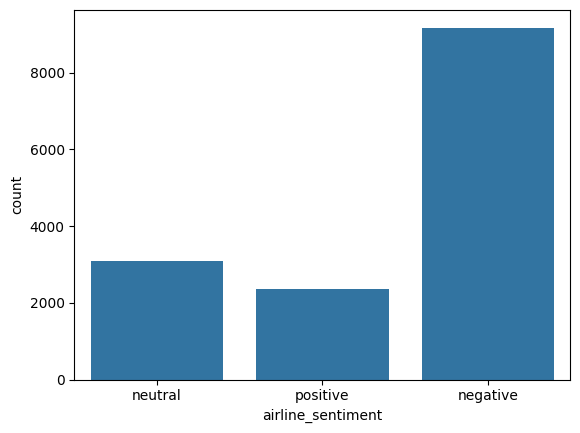

In [6]:
sns.countplot(x='airline_sentiment', data = df)

**Pré-Processamento**

In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Baixar pacotes necessários do NLTK
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab') # Download the 'punkt_tab' resource

[nltk_data] Downloading package stopwords to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
def preprocess_text(text):
    # Converter para minúsculas
    text = text.lower()

    # Remover caracteres especiais e números
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenização (dividir em palavras)
    tokens = word_tokenize(text)

    # Remover stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematização (reduzir palavras à sua forma base)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Juntar as palavras processadas de volta em uma string
    return " ".join(tokens)

In [9]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [10]:
df.head(5)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,clean_text
0,570306133677760513,neutral,1.0,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),virginamerica dhepburn said
1,570301130888122368,positive,3.486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada),virginamerica plus youve added commercial expe...
2,570301083672813571,neutral,6.837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada),virginamerica didnt today must mean need take ...
3,570301031407624196,negative,1.0,Bad Flight,7.033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada),virginamerica really aggressive blast obnoxiou...
4,570300817074462722,negative,1.0,Can't Tell,1.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada),virginamerica really big bad thing


<Axes: xlabel='airline_sentiment', ylabel='count'>

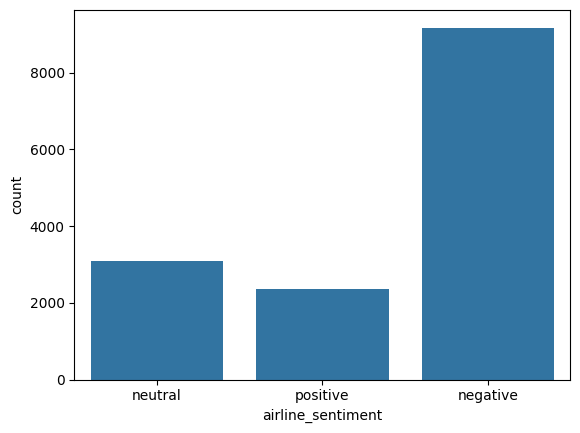

In [11]:
sns.countplot(x="airline_sentiment", data=df) # validando se mudou as classes

In [12]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['airline_sentiment'])

In [13]:
X = df['clean_text']
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#, stratify=y

In [14]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=None
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**XGBoost**

In [17]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    importance_type='gain',
    random_state=42,
    n_jobs=-1
)

In [18]:
# Mesma validação do Keras: validation_split=0.1 usa os últimos 10% do treino
val_size = int(0.1 * X_train_tfidf.shape[0])

X_tr, X_val = X_train_tfidf[:-val_size], X_train_tfidf[-val_size:]
y_tr, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]

model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=20
)

[0]	validation_0-mlogloss:0.89028	validation_1-mlogloss:0.91314
[20]	validation_0-mlogloss:0.68987	validation_1-mlogloss:0.81187
[40]	validation_0-mlogloss:0.62297	validation_1-mlogloss:0.78975
[60]	validation_0-mlogloss:0.58166	validation_1-mlogloss:0.77875
[80]	validation_0-mlogloss:0.55116	validation_1-mlogloss:0.76972
[100]	validation_0-mlogloss:0.52567	validation_1-mlogloss:0.76407
[120]	validation_0-mlogloss:0.50432	validation_1-mlogloss:0.75922
[140]	validation_0-mlogloss:0.48612	validation_1-mlogloss:0.75520
[160]	validation_0-mlogloss:0.47016	validation_1-mlogloss:0.75249
[180]	validation_0-mlogloss:0.45597	validation_1-mlogloss:0.74972
[199]	validation_0-mlogloss:0.44329	validation_1-mlogloss:0.74743


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


**Métricas**

In [19]:
from sklearn.metrics import classification_report

# Fazer previsões no conjunto de teste
y_pred = model.predict_proba(X_test_tfidf)      # probabilidades
y_pred_classes = model.predict(X_test_tfidf)    # classes (já em 0/1)

# Gerar o relatório de classificação
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1889
           1       0.61      0.42      0.49       580
           2       0.73      0.59      0.65       459

    accuracy                           0.77      2928
   macro avg       0.72      0.64      0.67      2928
weighted avg       0.76      0.77      0.76      2928



In [20]:
#acuracia,precisão, recall e f1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    return accuracy, precision, recall, f1
# Calcular as métricas
accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred_classes)
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.7708
Precisão: 0.7562
Recall: 0.7708
F1-Score: 0.7559


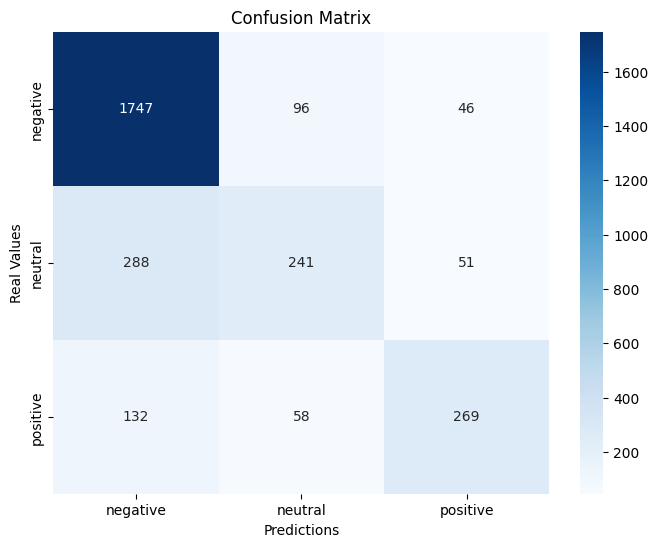

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcular a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Criar o heatmap da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predictions")
plt.ylabel("Real Values")
plt.title("Confusion Matrix")
plt.show()

**LIME**

In [22]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=le.classes_)

def predict_proba(texts):
    X = tfidf.transform(texts)          # mantém esparso
    return model.predict_proba(X)

idx = int(input(f"Digite o número da linha (0 a {len(X_test)-1}): "))
sample_text = X_test.iloc[idx]
sample_label = y_test.iloc[idx]

sample_tfidf = tfidf.transform([sample_text])   # sem .toarray()

pred_probs = model.predict_proba(sample_tfidf)
pred_class_idx = pred_probs.argmax(axis=1)[0]
pred_class_name = le.classes_[pred_class_idx]

print(f"Número da linha no X_test: {idx}")
print(f"Original text:\n{sample_text}")
print(f"Classe real: {le.classes_[sample_label]}")
print(f"Classe predita: {pred_class_name}")

explanation = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10
)

print(explanation.as_list())

Número da linha no X_test: 499
Original text:
americanair narrowly made standbylots snag trip
Classe real: negative
Classe predita: negative
[(np.str_('americanair'), 0.07165698508511635), (np.str_('snag'), -0.05654637288991553), (np.str_('made'), -0.026989148430820398), (np.str_('trip'), -0.012506615534291965), (np.str_('narrowly'), 0.0001713277046656673), (np.str_('standbylots'), -0.00010841724555123675)]


In [23]:
# Obtém as palavras mais importantes e seus pesos
lime_features = explanation.as_list()

# Exibe cada palavra com seu impacto na predição
print("Palavras mais importantes e seus pesos:")
for word, weight in lime_features:
    print(f"{word}: {weight:.4f}")

Palavras mais importantes e seus pesos:
americanair: 0.0717
snag: -0.0565
made: -0.0270
trip: -0.0125
narrowly: 0.0002
standbylots: -0.0001


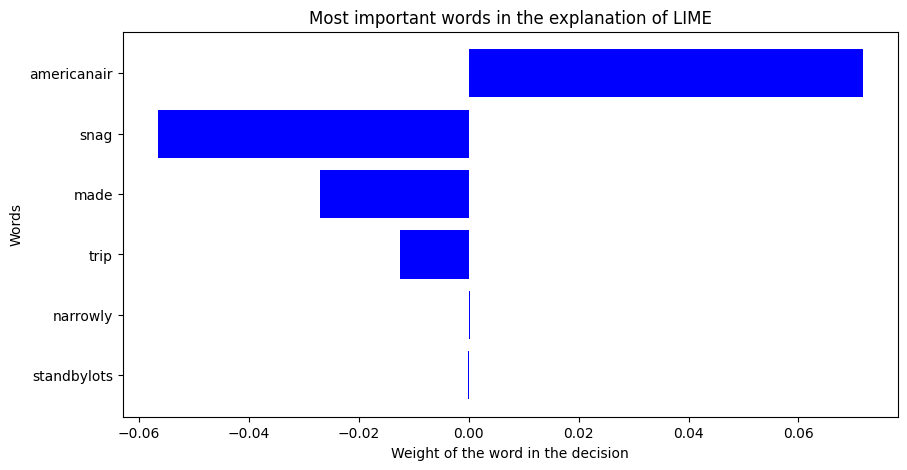

In [24]:
# Separar palavras e pesos
words, weights = zip(*lime_features)

# Criar gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color="blue")
plt.xlabel("Weight of the word in the decision")
plt.ylabel("Words")
plt.title("Most important words in the explanation of LIME")
plt.gca().invert_yaxis()  # Inverter para mostrar a palavra mais importante no topo
plt.show()

In [25]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Imprimir as palavras e pesos
for word, weight in words_weights:
    print(f"{word}: {weight}")

americanair: 0.07165698508511635
snag: -0.05654637288991553
made: -0.026989148430820398
trip: -0.012506615534291965
narrowly: 0.0001713277046656673
standbylots: -0.00010841724555123675


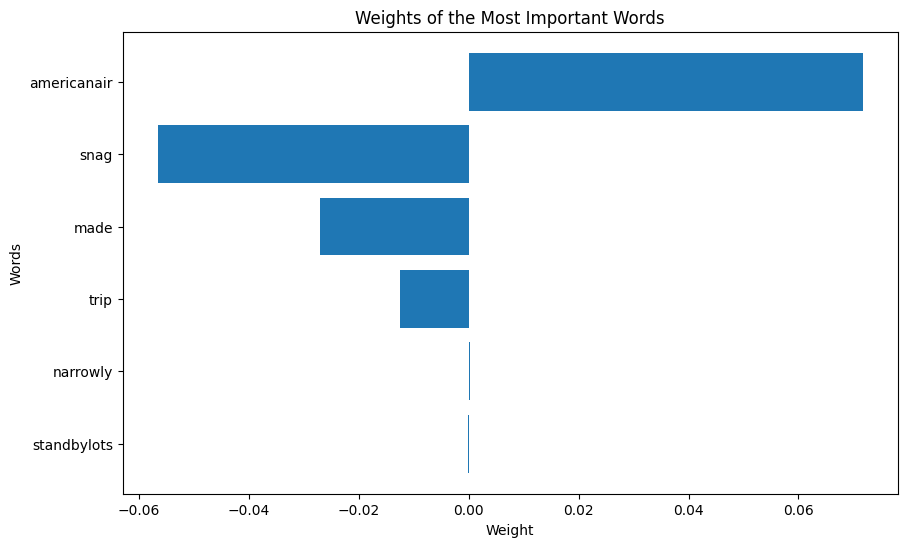

In [26]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Separar palavras e pesos em listas separadas
words = [word for word, weight in words_weights]
weights = [weight for word, weight in words_weights]

# Criar o gráfico de barras horizontais
plt.figure(figsize=(10, 6))  # Ajustar o tamanho da figura, se necessário
plt.barh(words, weights)
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Weights of the Most Important Words")
plt.gca().invert_yaxis()  # Inverter o eixo y para que as palavras mais importantes estejam no topo
plt.show()

**Attention Viz**

In [27]:
print(model)
print("Nº de árvores:", model.get_booster().num_boosted_rounds())
print("Nº de features:", model.n_features_in_)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type='gain',
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)
Nº de árvores: 200
Nº de features: 5000


Texto usado na explicação:
americanair narrowly made standbylots snag trip

Classe prevista: 0
Probabilidades: [0.4729557  0.41084245 0.11620189]
Importance: (5000,)
Número de palavras: 4
       Feature     TFIDF    Weight  Contribution
1         made  0.431623  0.001759      0.000759
3         trip  0.429696  0.000935      0.000402
0  americanair  0.213800  0.001430      0.000306
2         snag  0.763775  0.000000      0.000000


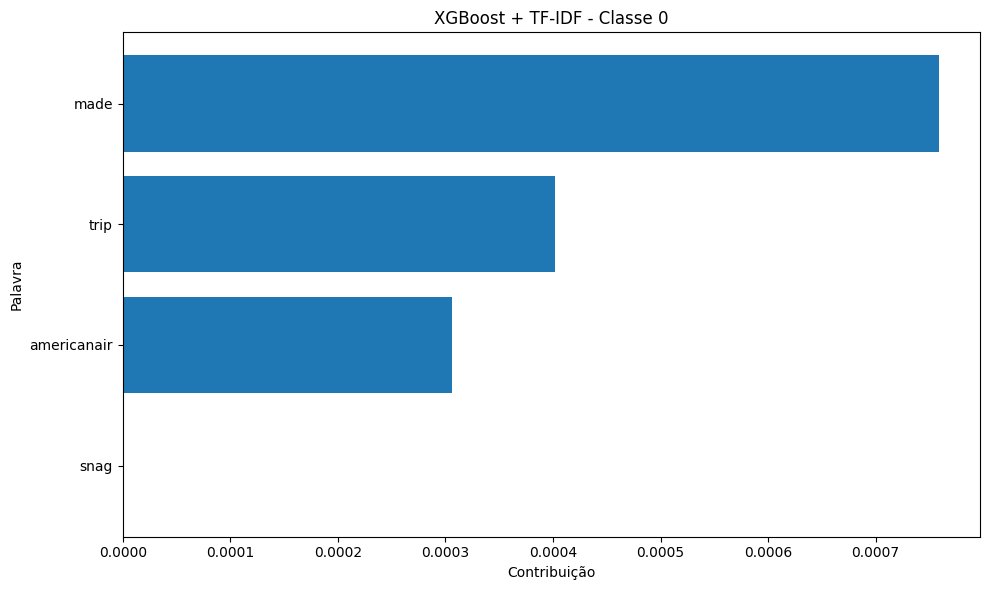

In [28]:
lime_idx = 499

sample_text = X_test.iloc[lime_idx]
print("Texto usado na explicação:")
print(sample_text)

# ETAPA 1: PREVISÃO
sample_tfidf = X_test_tfidf[lime_idx:lime_idx+1]
prediction = model.predict_proba(sample_tfidf)
predicted_class_index = np.argmax(prediction[0])

print(f"\nClasse prevista: {predicted_class_index}")
print("Probabilidades:", prediction[0])

# ETAPA 2: IMPORTÂNCIA GLOBAL DAS FEATURES (ganho médio dos splits)
feature_names = tfidf.get_feature_names_out()
global_importance = model.feature_importances_

print("Importance:", global_importance.shape)

# ETAPA 3: PALAVRAS PRESENTES NO TEXTO
tfidf_vector = sample_tfidf.toarray().flatten()
indices = np.where(tfidf_vector > 0)[0]
print("Número de palavras:", len(indices))

palavras = feature_names[indices]
pesos = global_importance[indices]
contribuicao = tfidf_vector[indices] * pesos

importancias = pd.DataFrame({
    "Feature": palavras,
    "TFIDF": tfidf_vector[indices],
    "Weight": pesos,
    "Contribution": contribuicao
}).sort_values(by="Contribution", ascending=False)

print(importancias.head(20))

# ETAPA 4: VISUALIZAÇÃO
top = importancias.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top["Feature"], top["Contribution"])
plt.xlabel("Contribuição")
plt.ylabel("Palavra")
plt.title(f"XGBoost + TF-IDF - Classe {predicted_class_index}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Shapley

Classe prevista: 0
Palavras: ['americanair' 'trip' 'snag' 'made']
TF-IDF: [0.21379974 0.4296958  0.76377522 0.43162322]
SHAP: [4.1947926e-05 0.0000000e+00 0.0000000e+00 0.0000000e+00]


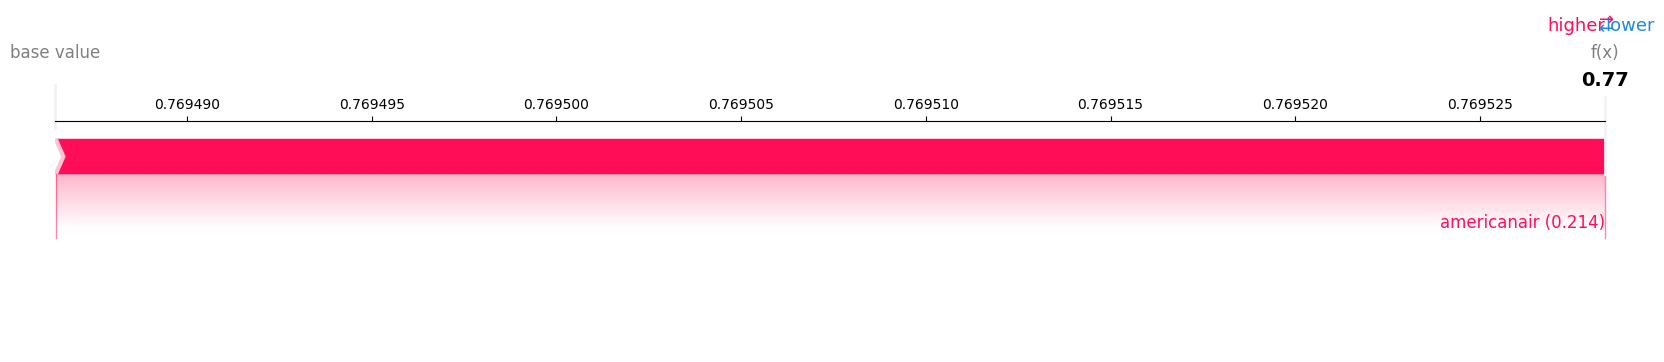

In [ ]:
lime_idx = 499

X_instance = X_test_tfidf[lime_idx:lime_idx+1]   # mantém esparso

# Classe prevista
pred_probs = model.predict_proba(X_instance)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
print("Classe prevista:", pred_class_idx)

# TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = np.array(explainer.shap_values(X_instance)).reshape(-1)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.array(expected_value).reshape(-1)[0])

# Palavras presentes no documento
feature_names = np.array(tfidf.get_feature_names_out())
tfidf_vector = X_instance.toarray().reshape(-1)
indices = np.where(tfidf_vector > 0)[0]

words = feature_names[indices]
values = shap_values[indices]
tfidf_values = tfidf_vector[indices]

# Ordenar por impacto absoluto
top_k = 15
order = np.argsort(np.abs(values))[::-1][:top_k]

words = words[order]
values = values[order]
tfidf_values = tfidf_values[order]

formatted_labels = [f"{w} ({t:.3f})" for w, t in zip(words, tfidf_values)]

print("Palavras:", words)
print("TF-IDF:", tfidf_values)
print("SHAP:", values)

shap.force_plot(
    base_value=expected_value,
    shap_values=values,
    #features=tfidf_values,
    feature_names=formatted_labels,
    matplotlib=True
)